# Med Center Shuttle Peak Hours Analysis and Recommendations

This notebook will analyze the APC ridership data to assist in optimizing bus deployment across the med center express shuttle. The analysis will use BusState files from March 2, 2026 - April 17, 2026, this represents 7 weeks worth of data collected M-F.

### Directions

**Inbound:** Carmack 2, 3, 5A and 5B -> University Hospital, Doan Hall

**Outbound:** University Hospital, Doan Hall -> Carmack 2, 3, 5A and 5B

### Key Variables Used
- STOP_ID:      The ID of the stop (401, 403, 404, 94, 95, 401, 37)
- ARRIVAL:      Arrival time of the bus at the current stop
- DEPARTURE:    Departure time of the bus at the current stop
- BOARDINGS:    Number of boardings detected by APC at the current stop 
- ALIGHTINGS:   Number of alightings detected by APC at the current stop
- HOUR:         Hour of event
- MINUTE:       Minute of event
- DATE:         Date of event

In [2]:
# %pip install statsmodels

import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.graphics.mosaicplot import mosaic

# Global config for analysis and viz

# boilerplate for all viz
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.grid':        True,
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

# seaborn styles set
sns.set_style("whitegrid", {
    'axes.facecolor': '#F8F8F6',
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
})

# stop id and names
STOP_NAMES = {
    37: 'Doan Hall',
    94: 'Carmack 5A',
    95: 'Carmack 5B',
    401: 'University Hospital',
    403: 'Carmack 2',
    404: 'Carmack 3'
}

# bus max capacity
BUS_CAPACITY = 65 # based on previous analysis, 65 is generally considered the max capacity for a cabs bus
BUS_CAPACITY_COMFORT = 50 # this is a guess of what a 'comfortable' capacity may be. Will cross reference with number of seats, etc in future
CARMACK_5_BEGINS = 7 # busses stop at carmack 5 starting after 7am according to run books


---

## Loading and Validation of Data

In [6]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

data_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours"
# going to have to rework the process_mc_busstate function to take in new dir

# month and date dict
timeframe_dict = {
    # 'JAN': 2026,
    # 'FEB': 2026,
    'MAR': 2026,
    'APR': 2026
}
# set dir to save cleaned files to 
repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

# loop through and concat to once single df
df = pd.DataFrame()
for month, year in timeframe_dict.items():
    df = pd.concat([df, mcd.process_mc_busstate(year=year, month=month, current_dir=data_dir, repo_dir=repo_dir)], ignore_index=True)

# This should only have to be run once per session. ~9 minutes to run

In [55]:
# Cut down df to necessary columns
mc_df = df[['DATE', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS', 'RUN_ID', 'ARRIVAL', 'DEPARTURE', 'DWELL', 'HOUR', 'MINUTE']].copy()
mc_df.columns = mc_df.columns.str.lower()

# map for inbound vs outbound stops
DIRECTION_MAP = {
    37: 'Outbound',
    94: 'Inbound',
    95: 'Inbound',
    401: 'Outbound',
    403: 'Inbound',
    404: 'Inbound'
}

# Parse and filter timeframe 3/2/2026 - 4/17/2026
mc_df['date'] = pd.to_datetime(mc_df['date'])
mc_df = mc_df[(mc_df['date'] >= '2026-03-02') & (mc_df['date'] <= '2026-04-17')]

# Parse time-related columns
mc_df['arrival'] = pd.to_datetime(mc_df['arrival'])
mc_df['departure'] = pd.to_datetime(mc_df['departure'])
mc_df['dwell'] = pd.to_timedelta(mc_df['dwell'], unit='s')
mc_df['time'] = pd.to_datetime(mc_df['date'].astype(str) + ' ' + mc_df['arrival'].dt.time.astype(str))

mc_df.sort_values(by='time', inplace=True)

# Normalize numeric dtypes
mc_df['stop_id'] = mc_df['stop_id'].astype(int)
mc_df['boardings'] = mc_df['boardings'].astype(int)
mc_df['alightings'] = mc_df['alightings'].astype(int)
mc_df['run_id'] = mc_df['run_id'].astype(int)

# Add convenience columns
mc_df['stop_name'] = mc_df['stop_id'].map(STOP_NAMES)
mc_df['weekday'] = mc_df['date'].dt.day_name()  # in case weekday-related patterns surface
mc_df['dwell_sec'] = mc_df['dwell'].dt.total_seconds()
mc_df['weekday_num'] = mc_df['date'].dt.weekday  # Monday=0, Sunday=6
mc_df['direction'] = mc_df['stop_id'].map(DIRECTION_MAP)

# Remove weekend rows currently out of scope
mc_df = mc_df[mc_df['weekday'] != 'Saturday']
mc_df = mc_df[mc_df['weekday'] != 'Sunday']

In [21]:
# Shape and data check
print(f'Records : {len(mc_df)}')
print(f'Date range : {mc_df["date"].min().date()}  - {mc_df["date"].max().date()}')
print(f'Unique dates : {mc_df["date"].dt.date.nunique()}')
print(mc_df.dtypes)
mc_df.head(3)

Records : 57852
Date range : 2026-03-02  - 2026-04-17
Unique dates : 35
date            datetime64[us]
stop_id                  int64
boardings                int64
alightings               int64
run_id                   int64
arrival         datetime64[us]
departure       datetime64[us]
dwell          timedelta64[us]
hour                     int32
minute                   int32
time            datetime64[us]
stop_name                  str
weekday                    str
dwell_sec              float64
weekday_num              int32
direction                  str
dtype: object


,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
16770,2026-03-02,403,0,0,1502,1900-01-01 00:22:07,1900-01-01 00:22:32,0 days 00:00:25,0,22,2026-03-02 00:22:07,Carmack 2,Monday,25.0,0,IB
16771,2026-03-02,404,0,0,1502,1900-01-01 00:23:10,1900-01-01 00:23:35,0 days 00:00:25,0,23,2026-03-02 00:23:10,Carmack 3,Monday,25.0,0,IB
16772,2026-03-02,94,0,0,1502,1900-01-01 00:24:19,1900-01-01 00:24:26,0 days 00:00:07,0,24,2026-03-02 00:24:19,Carmack 5A,Monday,7.0,0,IB


In [22]:
# Missing data check
missing = mc_df.isnull().sum()
missing

date           0
stop_id        0
boardings      0
alightings     0
run_id         0
arrival        0
departure      0
dwell          0
hour           0
minute         0
time           0
stop_name      0
weekday        0
dwell_sec      0
weekday_num    0
direction      0
dtype: int64

In [23]:
# Data ranges and distributions check
mc_df.describe()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,dwell_sec,weekday_num
count,57852,57852.000000,57852.000000,57852.000000,57852.000000,57852,57852,57852,57852.000000,57852.000000,57852,57852.000000,57852.000000
mean,2026-03-24 19:30:48.164281,247.100653,3.517389,3.456752,1504.327681,1900-01-01 13:18:41.402942,1900-01-01 13:19:51.549351,0 days 00:01:10.146408,12.816497,29.213078,2026-03-25 08:49:29.567223,70.146408,2.042954
min,2026-03-02 00:00:00,37.000000,0.000000,0.000000,1501.000000,1900-01-01 00:00:00,1900-01-01 00:00:06,0 days 00:00:00,0.000000,0.000000,2026-03-02 00:22:07,0.000000,0.000000
25%,2026-03-12 00:00:00,94.000000,0.000000,0.000000,1502.000000,1900-01-01 07:35:45.750000,1900-01-01 07:36:58.750000,0 days 00:00:35,7.000000,14.000000,2026-03-12 14:24:49.500000,35.000000,1.000000
50%,2026-03-24 00:00:00,401.000000,1.000000,1.000000,1504.000000,1900-01-01 14:13:41.500000,1900-01-01 14:15:16,0 days 00:00:53,14.000000,29.000000,2026-03-24 21:18:56,53.000000,2.000000
75%,2026-04-07 00:00:00,403.000000,5.000000,5.000000,1506.000000,1900-01-01 18:26:27.750000,1900-01-01 18:27:58.750000,0 days 00:01:27,18.000000,44.000000,2026-04-07 14:37:51.500000,87.000000,3.000000
max,2026-04-17 00:00:00,404.000000,53.000000,47.000000,1514.000000,1900-01-01 23:59:58,1900-01-01 23:59:59,0 days 00:22:43,23.000000,59.000000,2026-04-17 23:59:31,1363.000000,4.000000
std,NaN,165.668556,5.604419,5.331815,2.875062,NaN,NaN,0 days 00:00:53.986309,6.121214,17.495182,NaN,53.986310,1.415327



---
## Analysis and Visualization of the Data
**Notes:**
- mc_df denotes the dataframe with the busstate data for the sample of 3/1/2026 - 4/14/2026
- The sample timeframe of 3/1/2026 - 4/14/2026 was chosen due to the new hospital tower opening in late February 2026
    - This should give the best possible view of staffing and demand changes to the shuttle


---

## Key Metrics Summary

In [24]:
# Aggregate to hourly totals
hourly_mc_df = (
    mc_df.groupby('hour')
    .agg(
        total_boardings=('boardings', 'sum'),
        total_alightings=('alightings', 'sum'),
        avg_dwell_sec=('dwell_sec', 'mean')
    )
    .reset_index()
)

# Sanity check of total boardings and alightings
total_boardings = hourly_mc_df['total_boardings'].sum()
total_alightings = hourly_mc_df['total_alightings'].sum()

# Total number of each within 5000
e = total_boardings - total_alightings
print(f'Total boardings: {total_boardings}')
print(f'Total alightings: {total_alightings}')
print(f'Difference: {e}')
# The total boardings and alightings should theoretically be the same
# The difference is likely due to APC data collection error
# Given the large sample size, this small difference should not significantly impact the overall analysis
# Approximately 2.5% difference.

Total boardings: 203488
Total alightings: 199980
Difference: 3508


In [25]:
# summary stats
peak_hour   = hourly_mc_df.loc[hourly_mc_df['total_boardings'].idxmax(), 'hour']
peak_vol    = hourly_mc_df['total_boardings'].max()
avg_dwell   = hourly_mc_df['avg_dwell_sec'].mean()

peak_hour, peak_vol, avg_dwell

(np.int32(6), np.int64(26241), np.float64(69.09950776994985))


---

### Visualization 1: Total Hourly Boarding Volume

Broad overview to get an idea of the total demand and throughput of the shuttle through an hourly breakdown.

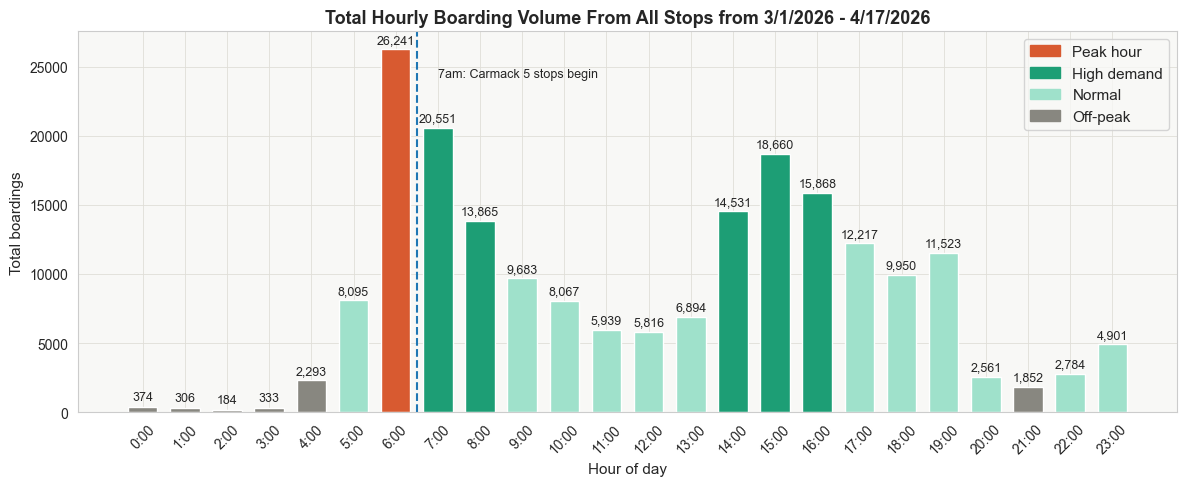

Lower Threshold (25th percentile): 2494.0
Upper Threshold (75th percentile): 12629.0


In [26]:
# Starting at 7am the busses will stop at the carmack stops too.

# define the quartiles for boardings for color coding
q1 = hourly_mc_df['total_boardings'].quantile(0.25)
q3 = hourly_mc_df['total_boardings'].quantile(0.75)

# plot the hourly boardings accross all stops to get a sense of overall traffic

TEAL   = '#1D9E75'       # high demand
GRAY   = '#888780'       # off-peak
CORAL  = '#D85A30'       # peak hour
LIGHT_TEAL   = '#9FE1CB' # 'normal' demand

fig, ax = plt.subplots(figsize=(12, 5))

# define colors for each demand level
def get_color(hour, boardings):
    if hour == peak_hour:
        return CORAL # peak capacity hour
    elif (boardings ) >= q3: # high demand
        return TEAL
    elif boardings <= q1: # low demand
        return GRAY
    return LIGHT_TEAL # normal

colors = [
    get_color(h, b)
    for h, b in zip(hourly_mc_df['hour'], hourly_mc_df['total_boardings'])
]

# x = hour, y =total boardings, color coded by demand
bars = ax.bar(
    hourly_mc_df['hour'],
    hourly_mc_df['total_boardings'],
    color=colors,
    width=0.7
)

# add the value to each bar
max_val = hourly_mc_df['total_boardings'].max()
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_val * 0.01,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# mark time when carmack 5 stops start
ax.axvline(CARMACK_5_BEGINS - 0.5, linestyle='--', linewidth=1.5)

ax.text(
    CARMACK_5_BEGINS,
    max_val * 0.95,
    '7am: Carmack 5 stops begin',
    fontsize=9,
    va='top'
)

# legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Peak hour'),
    mpatches.Patch(color=TEAL, label='High demand'),
    mpatches.Patch(color=LIGHT_TEAL, label='Normal'),
    mpatches.Patch(color=GRAY, label='Off-peak')
])

# format axes
ax.set(
    xticks=hourly_mc_df['hour'],
    xticklabels=[f'{h}:00' for h in hourly_mc_df['hour']],
    xlabel='Hour of day',
    ylabel='Total boardings',
    title='Total Hourly Boarding Volume From All Stops from 3/1/2026 - 4/17/2026'
)
# make easier to see
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('1_total_hourly_boardings_all_stops.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Lower Threshold (25th percentile): {q1}')
print(f'Upper Threshold (75th percentile): {q3}')

### **Interpretation:**

Peak hourly boarding volume is within the 0600 hour. This makes sense with a moderately standardized 0700 shift start. This peak is followed by 2 more hours of high demand until leveling out at 0900. Afternoon peak is less concentrated and begins in the 1400 hour and does not reach 'off peak' until 2100. 


---

### Visualization 2: Day of Week Patterns

Determine if there is a difference in demand for specific days of the week

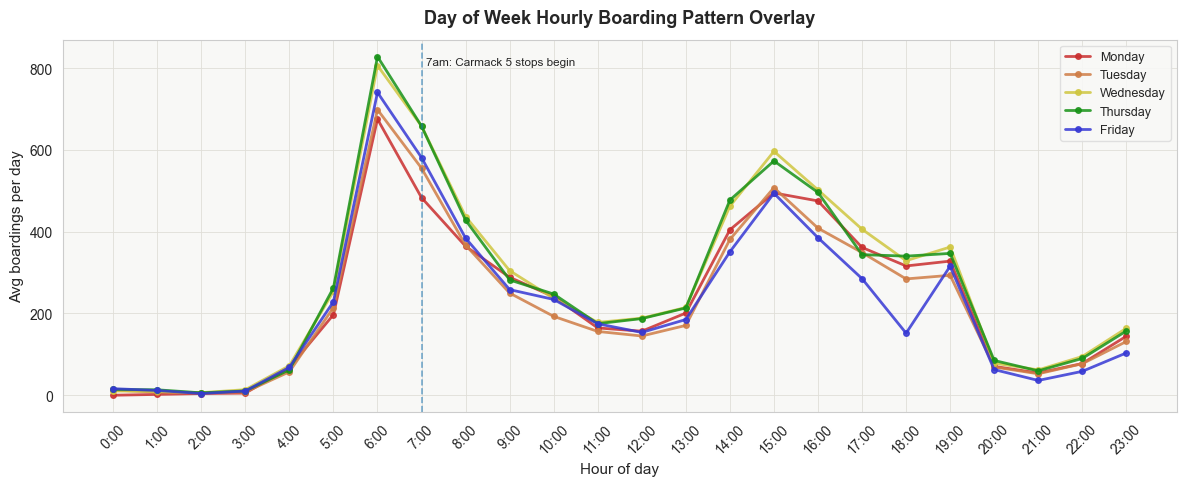

In [27]:
# set order and colors for days
colors = {
    'Monday': '#C92E2E',
    'Tuesday': '#CF7D46',
    'Wednesday': '#CFC640',
    'Thursday': '#179217',
    'Friday': '#3638D4'
}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Subset data into hourly boardings by day of week
hourly_by_day = (
    mc_df[mc_df['weekday'].isin(day_order)]
    .groupby(['weekday', 'weekday_num', 'hour'])['boardings']
    .sum()
    .reset_index()
    .sort_values(['weekday_num', 'hour'])
)

# Normalize to per-occurrence average (divide by number of each weekday in sample)
day_counts = mc_df.groupby('weekday')['date'].apply(lambda x: x.dt.date.nunique())
hourly_by_day['avg_boardings'] = hourly_by_day.apply(
    lambda r: r['boardings'] / day_counts.get(r['weekday'], 1), axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))

for day in day_order:
    subset = hourly_by_day[(hourly_by_day['weekday'] == day)]
    color = colors[day]

    ax.plot(subset['hour'], subset['avg_boardings'], marker='o', markersize=4, linewidth=2, color=color, label=day, alpha=0.85)

# Indicate when carmack 5 stops begin
ax.axvline(x=CARMACK_5_BEGINS, linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.text(CARMACK_5_BEGINS + 0.1, ax.get_ylim()[1] * 0.95,
        '7am: Carmack 5 stops begin', fontsize=8.5, va='top')

ax.set_xticks(range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(hourly_by_day['hour'].min(), hourly_by_day['hour'].max() + 1)],
                    rotation=45)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg boardings per day')
ax.set_title('Day of Week Hourly Boarding Pattern Overlay', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig('2_hourly_boardings_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation**

The days of the week have generally the same curve. The morning hour has a clear steep peak at 0600. Afternoon peak is visivle again, peaking at 1500 with a more shallow descent until the 2000 hour. There is a statistically significant drop in boardings at the 1800 hour for Fridays. This is likely due to on site parking opening up for weekend staffing at this time. Due to staffing strategy and since the demand "peaks" again at 1900 to match the other days, my recommendation would be to not consider this in staffing the shuttle. 


---

## Visualization 3: Stop by Stop Boarding

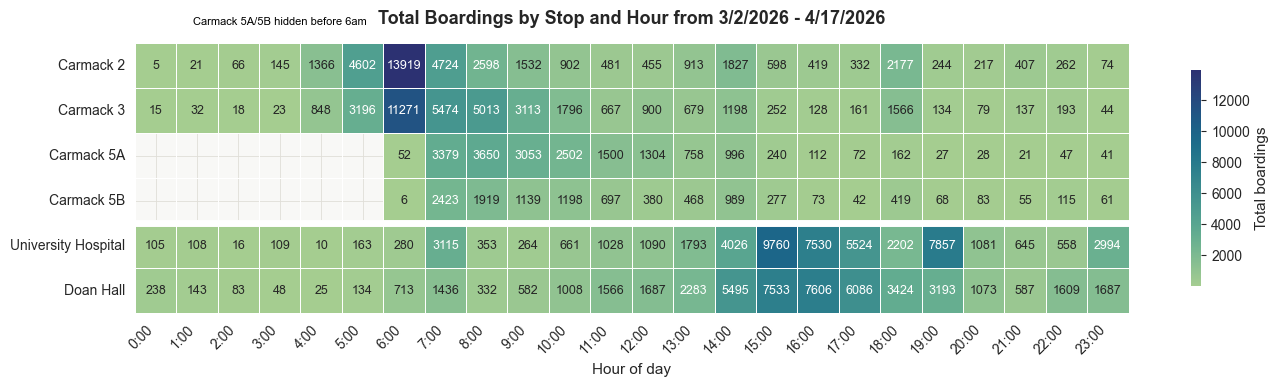

In [40]:
# create a df with hourly boardings by stop
hourly_by_stop = (
    mc_df.groupby(['stop_name', 'hour'])['boardings']
    .sum()
    .reset_index()
    .astype({'boardings': float})
 )

# Hide Carmack 5A/5B cells before 6am in the heatmap
hide_mask = hourly_by_stop['stop_name'].isin(['Carmack 5A', 'Carmack 5B']) & (hourly_by_stop['hour'] < 6)
hourly_by_stop.loc[hide_mask, 'boardings'] = np.nan

# order the stops
stops_order = ['Carmack 2', 'Carmack 3', 'Carmack 5A', 'Carmack 5B', 'University Hospital', 'Doan Hall'] 

pivot = (
    hourly_by_stop
    .pivot(index='stop_name', columns='hour', values='boardings')
    .reindex(stops_order)
)
mask = pivot.isna()

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='crest',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f', 
    annot_kws={'size': 9},
    cbar_kws={'label': 'Total boardings', 'shrink': 0.8},
    mask=mask
)

# Draw divider between parking and med-center rows
parking_rows = sum(1 for r in stops_order if 'Carmack' in r and r in hourly_by_stop['stop_name'].unique())
ax.axhline(y=parking_rows, color='white', linewidth=5)

ax.text(3.5, -0.4, 'Carmack 5A/5B hidden before 6am', ha='center', fontsize=8, color='black', zorder=6)

ax.set_xticklabels([f'{h}:00' for h in pivot.columns], rotation=45, ha='right')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
ax.set_title('Total Boardings by Stop and Hour from 3/2/2026 - 4/17/2026', pad=14)

plt.tight_layout()
# plt.savefig('3_hourly_boardings_by_stop.png', dpi=150, bbox_inches='tight')
plt.show()

### **Interpretation:**

- 9am hour drops to 3 busses. 
- 


---

## Visualization 3a: Mosaic Plot of Stop Traffic

c:\Users\morgan.1461\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


(<Figure size 1150x550 with 3 Axes>,
 {('Inbound', 'Carmack 2'): (0.0,
   np.float64(0.0),
   0.49935497473088936,
   np.float64(0.3463083120266294)),
  ('Inbound', 'Carmack 3'): (0.0,
   np.float64(0.35880831202662933),
   0.49935497473088936,
   np.float64(0.3341062038689758)),
  ('Inbound', 'Carmack 5A'): (0.0,
   np.float64(0.7054145158956051),
   0.49935497473088936,
   np.float64(0.16245356746586906)),
  ('Inbound', 'Carmack 5B'): (0.0,
   np.float64(0.8803680833614743),
   0.49935497473088936,
   np.float64(0.09463191663852577)),
  ('Inbound', 'Doan Hall'): (0.0,
   np.float64(0.9874999999999999),
   0.49935497473088936,
   np.float64(0.0)),
  ('Inbound', 'University Hospital'): (0.0,
   np.float64(1.0),
   0.49935497473088936,
   np.float64(0.0)),
  ('Outbound', 'Carmack 2'): (0.5189628178681442,
   np.float64(0.0),
   0.48103718213185576,
   np.float64(0.0)),
  ('Outbound', 'Carmack 3'): (0.5189628178681442,
   np.float64(0.0125),
   0.48103718213185576,
   np.float64(0.0)),
 

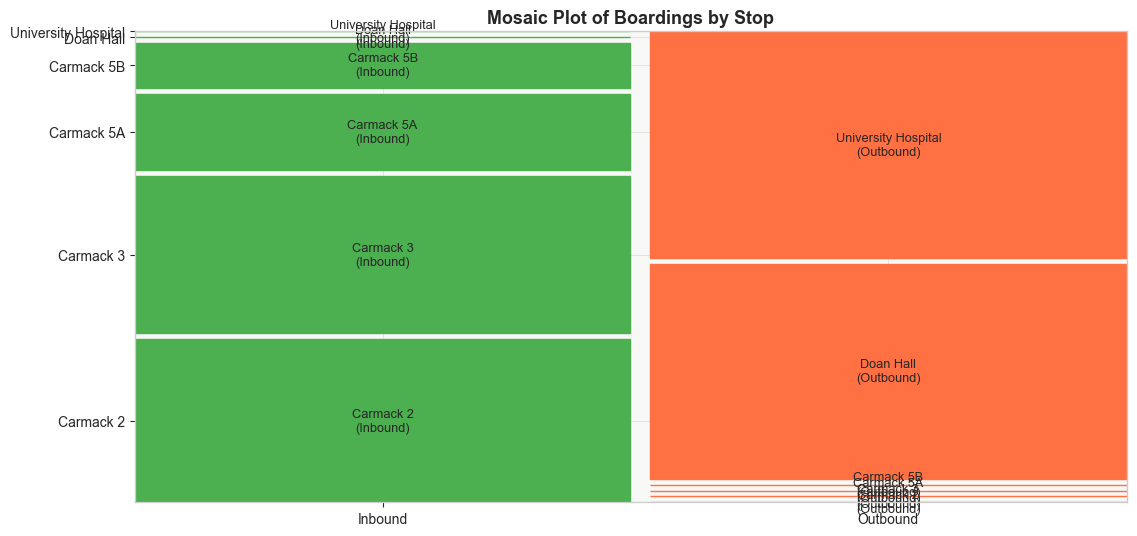

In [74]:
# no seaborn for mosaic plots
# build direction labels so inbound/outbound stops are their own rows
from statsmodels.graphics.mosaicplot import mosaic

mosaic_mc_df = (
    mc_df.groupby(['direction', 'stop_name'], observed=True)['boardings']
    .sum()
    .reset_index()
)

inbound_stops = [
    'Carmack 2',
    'Carmack 3',
    'Carmack 5A',
    'Carmack 5B'
]

outbound_stops = [
    'University Hospital',
    'Doan Hall'
]

mosaic_mc_df = mc_df[
    ((mc_df['direction'] == 'Inbound') & (mc_df['stop_name'].isin(inbound_stops))) |
    ((mc_df['direction'] == 'Outbound') & (mc_df['stop_name'].isin(outbound_stops)))
].groupby(['direction', 'stop_name'], observed=True)['boardings'].sum().reset_index()

mosaic_mc_df = mosaic_mc_df.sort_values(['direction', 'stop_name'])

mosaic_data = (
    mosaic_mc_df
    .set_index(['direction', 'stop_name'])['boardings']
    .to_dict()
)

# control function over formatting
def labelizer(key):
    direction, stop = key
    return f'{stop}\n({direction})'

def props(key):
    direction, stop = key
    return {
        'color': '#4CAF50' if direction == 'Inbound' else '#FF7043',
        'edgecolor': 'white'
    }

mosaic(
    mosaic_data,
    labelizer=labelizer,
    properties=props,
    title='Mosaic Plot of Boardings by Stop',
    gap=0.02
)



---

## Visualization 4: Boarding Direction Split

In [75]:
# Bus load metric: average boardings per completed trip, split inbound vs outbound
# BUS_CAPACITY_COMFORT is the comfortable threshold of 50 passengers on a bus.

# inbound vs outbound stops
# inbound: all carmack
INBOUND_STOPS = {
    'Carmack 2': 403,
    'Carmack 3': 404,
    'Carmack 5A': 94,
    'Carmack 5B': 95
}

# outbound: doan and uh
OUTBOUND_STOPS = {
    'Doan Hall': 37,
    'University Hospital': 401
}

# stop_id lookup
inbound_ids = set(INBOUND_STOPS.values())
outbound_ids = set(OUTBOUND_STOPS.values())
expected_stop_counts = {
    'Inbound': len(inbound_ids),
    'Outbound': len(outbound_ids)
}

trip_events = (
    mc_df[mc_df['stop_id'].isin(inbound_ids | outbound_ids)]
    .sort_values(['date', 'run_id', 'time', 'stop_id'])
    .copy()
)

trip_events['direction'] = trip_events['stop_id'].apply(
    lambda s: 'Inbound' if s in inbound_ids else 'Outbound'
)

# Stop-level metric: average boardings contributed by each bus at each stop within each hour.
per_stop_hour = (
    trip_events.groupby(['date', 'run_id', 'stop_id', 'direction', 'hour'], as_index=False)
    .agg(total_boardings=('boardings', 'sum'))
)

avg_boardings_per_bus = (
    per_stop_hour.groupby(['stop_id', 'direction', 'hour'], as_index=False)
    .agg(
        avg_boardings_per_bus=('total_boardings', 'mean'),
        n_observations=('total_boardings', 'count')
    )
    .sort_values(['direction', 'stop_id', 'hour'])
)

def assign_trip_ids(group):
    group = group.sort_values(['time', 'stop_id']).copy()
    trip_number = 0
    seen_stops = set()
    trip_ids = []

    for stop_id in group['stop_id']:
        if stop_id in seen_stops:
            trip_number += 1
            seen_stops = set()
        trip_ids.append(trip_number)
        seen_stops.add(stop_id)

    group['trip_id'] = trip_ids
    return group

# Build actual trip units across the full ordered run, not inside hour buckets.
trip_groups = []
for (date, run_id, direction), group in trip_events.groupby(['date', 'run_id', 'direction'], sort=False):
    group = assign_trip_ids(group)
    group['date'] = date
    group['run_id'] = run_id
    group['direction'] = direction
    trip_groups.append(group)

trip_events = pd.concat(trip_groups, ignore_index=True)

ib_ob_trip_boardings = (
    trip_events.groupby(['date', 'run_id', 'direction', 'trip_id'], as_index=False)
    .agg(
        trip_start=('time', 'min'),
        trip_end=('time', 'max'),
        total_trip_boardings=('boardings', 'sum'),
        stop_visits=('stop_id', 'count'),
        unique_stop_count=('stop_id', 'nunique')
    )
    .assign(
        expected_stop_count=lambda d: d['direction'].map(expected_stop_counts),
        is_complete_trip=lambda d: d['unique_stop_count'] == d['expected_stop_count'],
        hour=lambda d: d['trip_end'].dt.hour
    )
)

completed_trips = ib_ob_trip_boardings[ib_ob_trip_boardings['is_complete_trip']].copy()

direction_hourly = (
    completed_trips.groupby(['direction', 'hour'], as_index=False)
    .agg(
        avg_direction_boardings_per_trip=('total_trip_boardings', 'mean'),
        trips_observed=('trip_id', 'count')
    )
    .assign(
        percent_of_capacity=lambda d: (d['avg_direction_boardings_per_trip'] / BUS_CAPACITY_COMFORT) * 100
    )
    .sort_values(['direction', 'hour'])
)

print(f'Completed trips retained: {len(completed_trips):,} of {len(ib_ob_trip_boardings):,}')
#display(direction_hourly)
print(f'Max completed-trip boardings: {completed_trips["total_trip_boardings"].max()}')
#display(completed_trips.nlargest(5, 'total_trip_boardings'))

Completed trips retained: 18,339 of 20,666
Max completed-trip boardings: 75


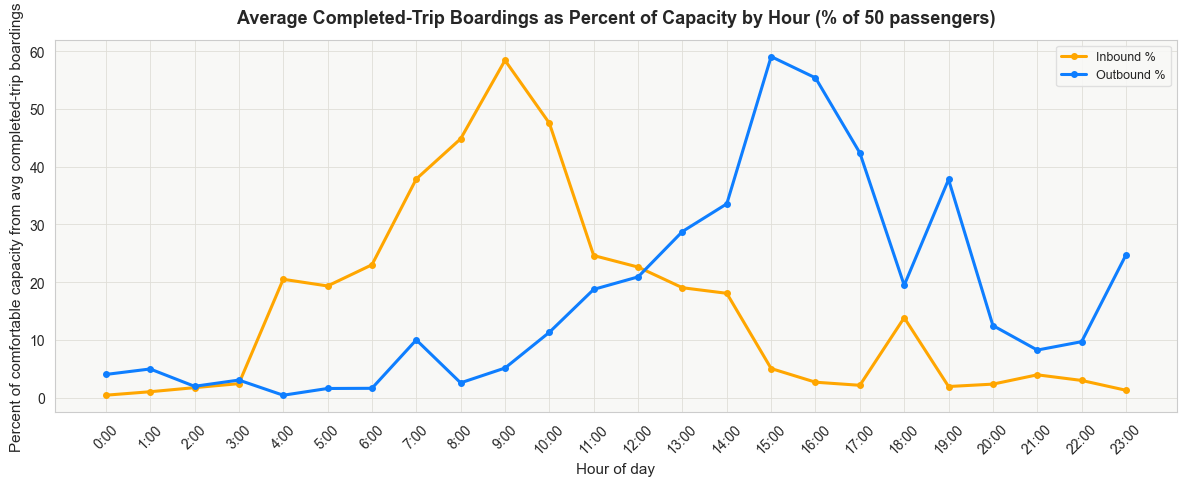

In [80]:
# viz
fig, ax = plt.subplots(figsize=(12, 5))

for direction, line_color in [('Inbound', "#ffa600"), ('Outbound', "#0e7eff")]:
    subset = direction_hourly[direction_hourly['direction'] == direction]
    ax.plot(
        subset['hour'],
        subset['percent_of_capacity'],
        marker='o',
        markersize=4,
        linewidth=2.2,
        color=line_color,
        label=f'{direction} %'
    )

ax.set_xticks(range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1))
ax.set_xticklabels([f'{h}:00' for h in range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1)],
                    rotation=45)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Percent of comfortable capacity from avg completed-trip boardings')
ax.set_title('Average Completed-Trip Boardings as Percent of Capacity by Hour (% of 50 passengers)', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
# plt.savefig('4_average_completed_trip_boardings_percent_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

# direction_hourly

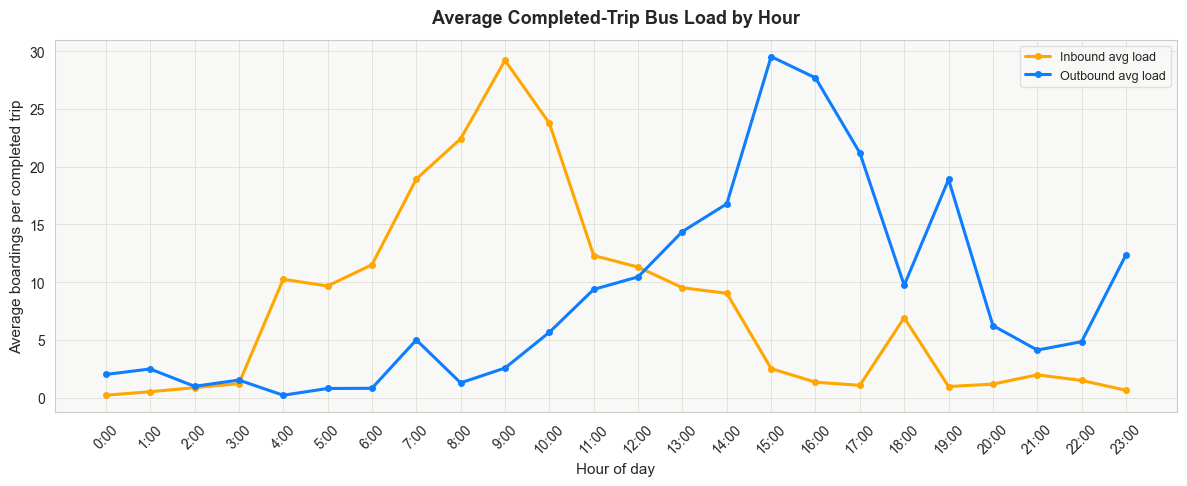

In [ ]:
# viz: same trend plot, using average bus load (boardings per completed trip) instead of % capacity
fig, ax = plt.subplots(figsize=(12, 5))

for direction, line_color in [('Inbound', "#ffa600"), ('Outbound', "#0e7eff")]:
    subset = direction_hourly[direction_hourly['direction'] == direction]
    ax.plot(
        subset['hour'],
        subset['avg_direction_boardings_per_trip'],
        marker='o',
        markersize=4,
        linewidth=2.2,
        color=line_color,
        label=f'{direction} avg load'
    )

ax.set_xticks(range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1))
ax.set_xticklabels(
    [f'{h}:00' for h in range(direction_hourly['hour'].min(), direction_hourly['hour'].max() + 1)],
    rotation=45
)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Average boardings per completed trip')
ax.set_title('Average Completed-Trip Bus Load by Hour', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
plt.show()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
16770,2026-03-02,403,0,0,1502,1900-01-01 00:22:07,1900-01-01 00:22:32,0 days 00:00:25,0,22,2026-03-02 00:22:07,Carmack 2,Monday,25.0,0,Inbound
16771,2026-03-02,404,0,0,1502,1900-01-01 00:23:10,1900-01-01 00:23:35,0 days 00:00:25,0,23,2026-03-02 00:23:10,Carmack 3,Monday,25.0,0,Inbound
16772,2026-03-02,94,0,0,1502,1900-01-01 00:24:19,1900-01-01 00:24:26,0 days 00:00:07,0,24,2026-03-02 00:24:19,Carmack 5A,Monday,7.0,0,Inbound
16773,2026-03-02,95,0,0,1502,1900-01-01 00:25:02,1900-01-01 00:26:20,0 days 00:01:18,0,25,2026-03-02 00:25:02,Carmack 5B,Monday,78.0,0,Inbound
16774,2026-03-02,94,0,0,1502,1900-01-01 00:26:50,1900-01-01 00:26:50,0 days 00:00:00,0,26,2026-03-02 00:26:50,Carmack 5A,Monday,0.0,0,Inbound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41404,2026-04-17,37,0,0,1502,1900-01-01 23:55:07,1900-01-01 23:56:17,0 days 00:01:10,23,55,2026-04-17 23:55:07,Doan Hall,Friday,70.0,4,Outbound
37661,2026-04-17,94,0,0,1504,1900-01-01 23:55:48,1900-01-01 23:55:58,0 days 00:00:10,23,55,2026-04-17 23:55:48,Carmack 5A,Friday,10.0,4,Inbound
37662,2026-04-17,95,0,0,1504,1900-01-01 23:56:31,1900-01-01 23:58:57,0 days 00:02:26,23,56,2026-04-17 23:56:31,Carmack 5B,Friday,146.0,4,Inbound
38371,2026-04-17,403,0,1,1501,1900-01-01 23:58:02,1900-01-01 23:58:23,0 days 00:00:21,23,58,2026-04-17 23:58:02,Carmack 2,Friday,21.0,4,Inbound


Text(0.5, 1.0, 'Unique Runs Observed by Hour')

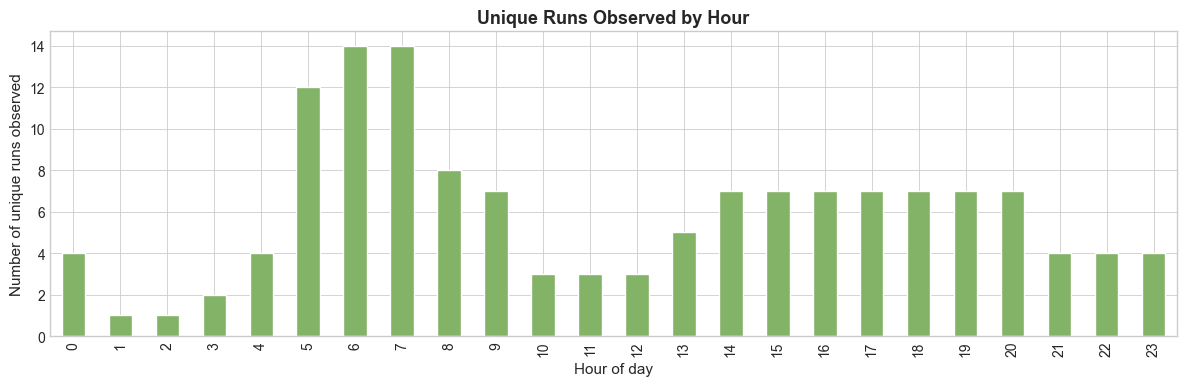

In [95]:
# find the number of unique runs observed in each hour
display(mc_df)

bus_counts = (
    mc_df.groupby('hour')['run_id']
    .nunique()
    .reindex(range(24), fill_value=0)
)

bus_counts.plot(kind='bar', color='#82b366', figsize=(12, 4))
plt.xlabel('Hour of day')
plt.ylabel('Number of unique runs observed')
plt.title('Unique Runs Observed by Hour')



---

## Visualization 5: Recommended Buses Per Hour


---

## Visualization 6: Final Recommendations

Current Headway Targets (4/21/2026):
| **Time Period** | **Target Headway** (minutes) | Notes:                       |
|-----------------|------------------------------|------------------------------|
| 0000 - 0500     | 20                           | 1 bus running                |
| 0500 - 0600     | 10                           |                              |
| 0600 - 0800     | 3                            | Current peak morning hours   |
| 0800 - 1400     | 10                           |                              |
| 1400 - 2000     | 5                            | Current peak afternoon hours |
| 2000 - 2200     | 10                           |                              |
| 2200 - 0000     | 5                            | "Second" afternoon peak      |